<a href="https://colab.research.google.com/github/madan-genai/LangGraph/blob/main/Subgraph_shared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langgraph langchain_google_genai langchain_core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.5 MB/s eta 0:00:00


In [2]:
import os
os.environ["GEMINI_API_KEY"] = ""

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

In [4]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [6]:
class ParentState(TypedDict):
  question :str
  answer_urdu : str
  answer_eng :str

In [7]:
def translate_text(state:ParentState):
   prompt = f"""
Translate the following text to Urdu.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
   translated_text = llm.invoke(prompt).content
   return {"answer_urdu":translated_text}


In [8]:
graph = StateGraph(ParentState)
graph.add_node("translate_text",translate_text)
graph.add_edge(START, "translate_text")
graph.add_edge("translate_text", END)
subgraph = graph.compile()

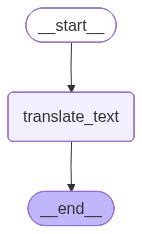

In [9]:
subgraph

In [11]:
def generate_answer(state:ParentState):
  answer = llm.invoke(f"You are helpful assistant.Answer clearly.\n\nQuestion: {state['question']}").content
  return {"answer_eng":answer}

In [12]:
parent_graph = StateGraph(ParentState)
parent_graph.add_node("answer",generate_answer)
parent_graph.add_node("translate",subgraph)
parent_graph.add_edge(START,"answer")
parent_graph.add_edge("answer","translate")
parent_graph.add_edge("translate",END)

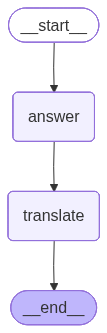

In [13]:
graph = parent_graph.compile()
graph

In [14]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_urdu': 'کوانٹم فزکس، جسے کوانٹم میکینکس بھی کہا جاتا ہے، طبیعیات کا ایک بنیادی نظریہ ہے جو ایٹمی اور ذیلی ایٹمی سطح پر مادے اور توانائی کے رویے کو بیان کرتا ہے۔ یہ \'انتہائی چھوٹے\' کی سائنس ہے، جہاں کلاسیکی فزکس (جو ہمارے روزمرہ کے تجربات کی دنیا کو بیان کرتی ہے) کے اصول لاگو نہیں ہوتے۔\n\nاس کے اہم پہلوؤں کا خلاصہ ذیل میں دیا گیا ہے:\n\n1.  **انتہائی چھوٹی چیزوں کا مطالعہ:** کوانٹم فزکس الیکٹران، پروٹون، نیوٹران، فوٹون (روشنی کے ذرات) جیسے ذرات اور ان کے باہمی تعاملات سے متعلق ہے۔ اس انتہائی چھوٹی سطح پر، مادہ اور توانائی ایسے طریقوں سے برتاؤ کرتے ہیں جو ہمارے روزمرہ کے تجربات کے مقابلے میں غیر متوقع اور "عجیب" لگ سکتے ہیں۔\n\n2.  **کوانٹائزیشن (مقدار بندی):** یہ سب سے بنیادی تصورات میں سے ایک ہے۔ اس کا مطلب ہے کہ بعض طبعی خصوصیات، جیسے توانائی، مومینٹم اور زاویائی مومینٹم، ایک مسلسل رینج میں موجود نہیں ہوتے بلکہ **کوانٹا** کہلانے والے الگ الگ "پیکٹس" یا "گچھوں" کی شکل میں ہوتے ہیں۔\n    *   **تشبیہ:** تصور کریں کہ ایک ڈھلوان ہے جہاں آ